In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [7]:
df=pd.read_csv(r"WineQT.csv")             #load dataset
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [8]:
df.shape

(1143, 13)

In [9]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

In [10]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

In [11]:
df.isnull().sum()         #check missing values

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [12]:
df.duplicated().sum()             #check duplicate rows

np.int64(0)

In [13]:
df.info()             #basic information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [14]:
df.describe()                  #summary statistics

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [15]:
#class distribution of wine quality
df["quality"].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

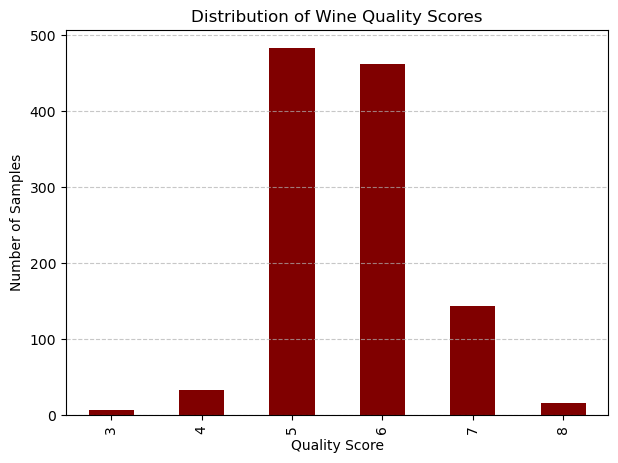

In [24]:
#visualize class distribution
plt.figure(figsize=(7,5))
df["quality"].value_counts().sort_index().plot(kind="bar",color="maroon",)

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Samples")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

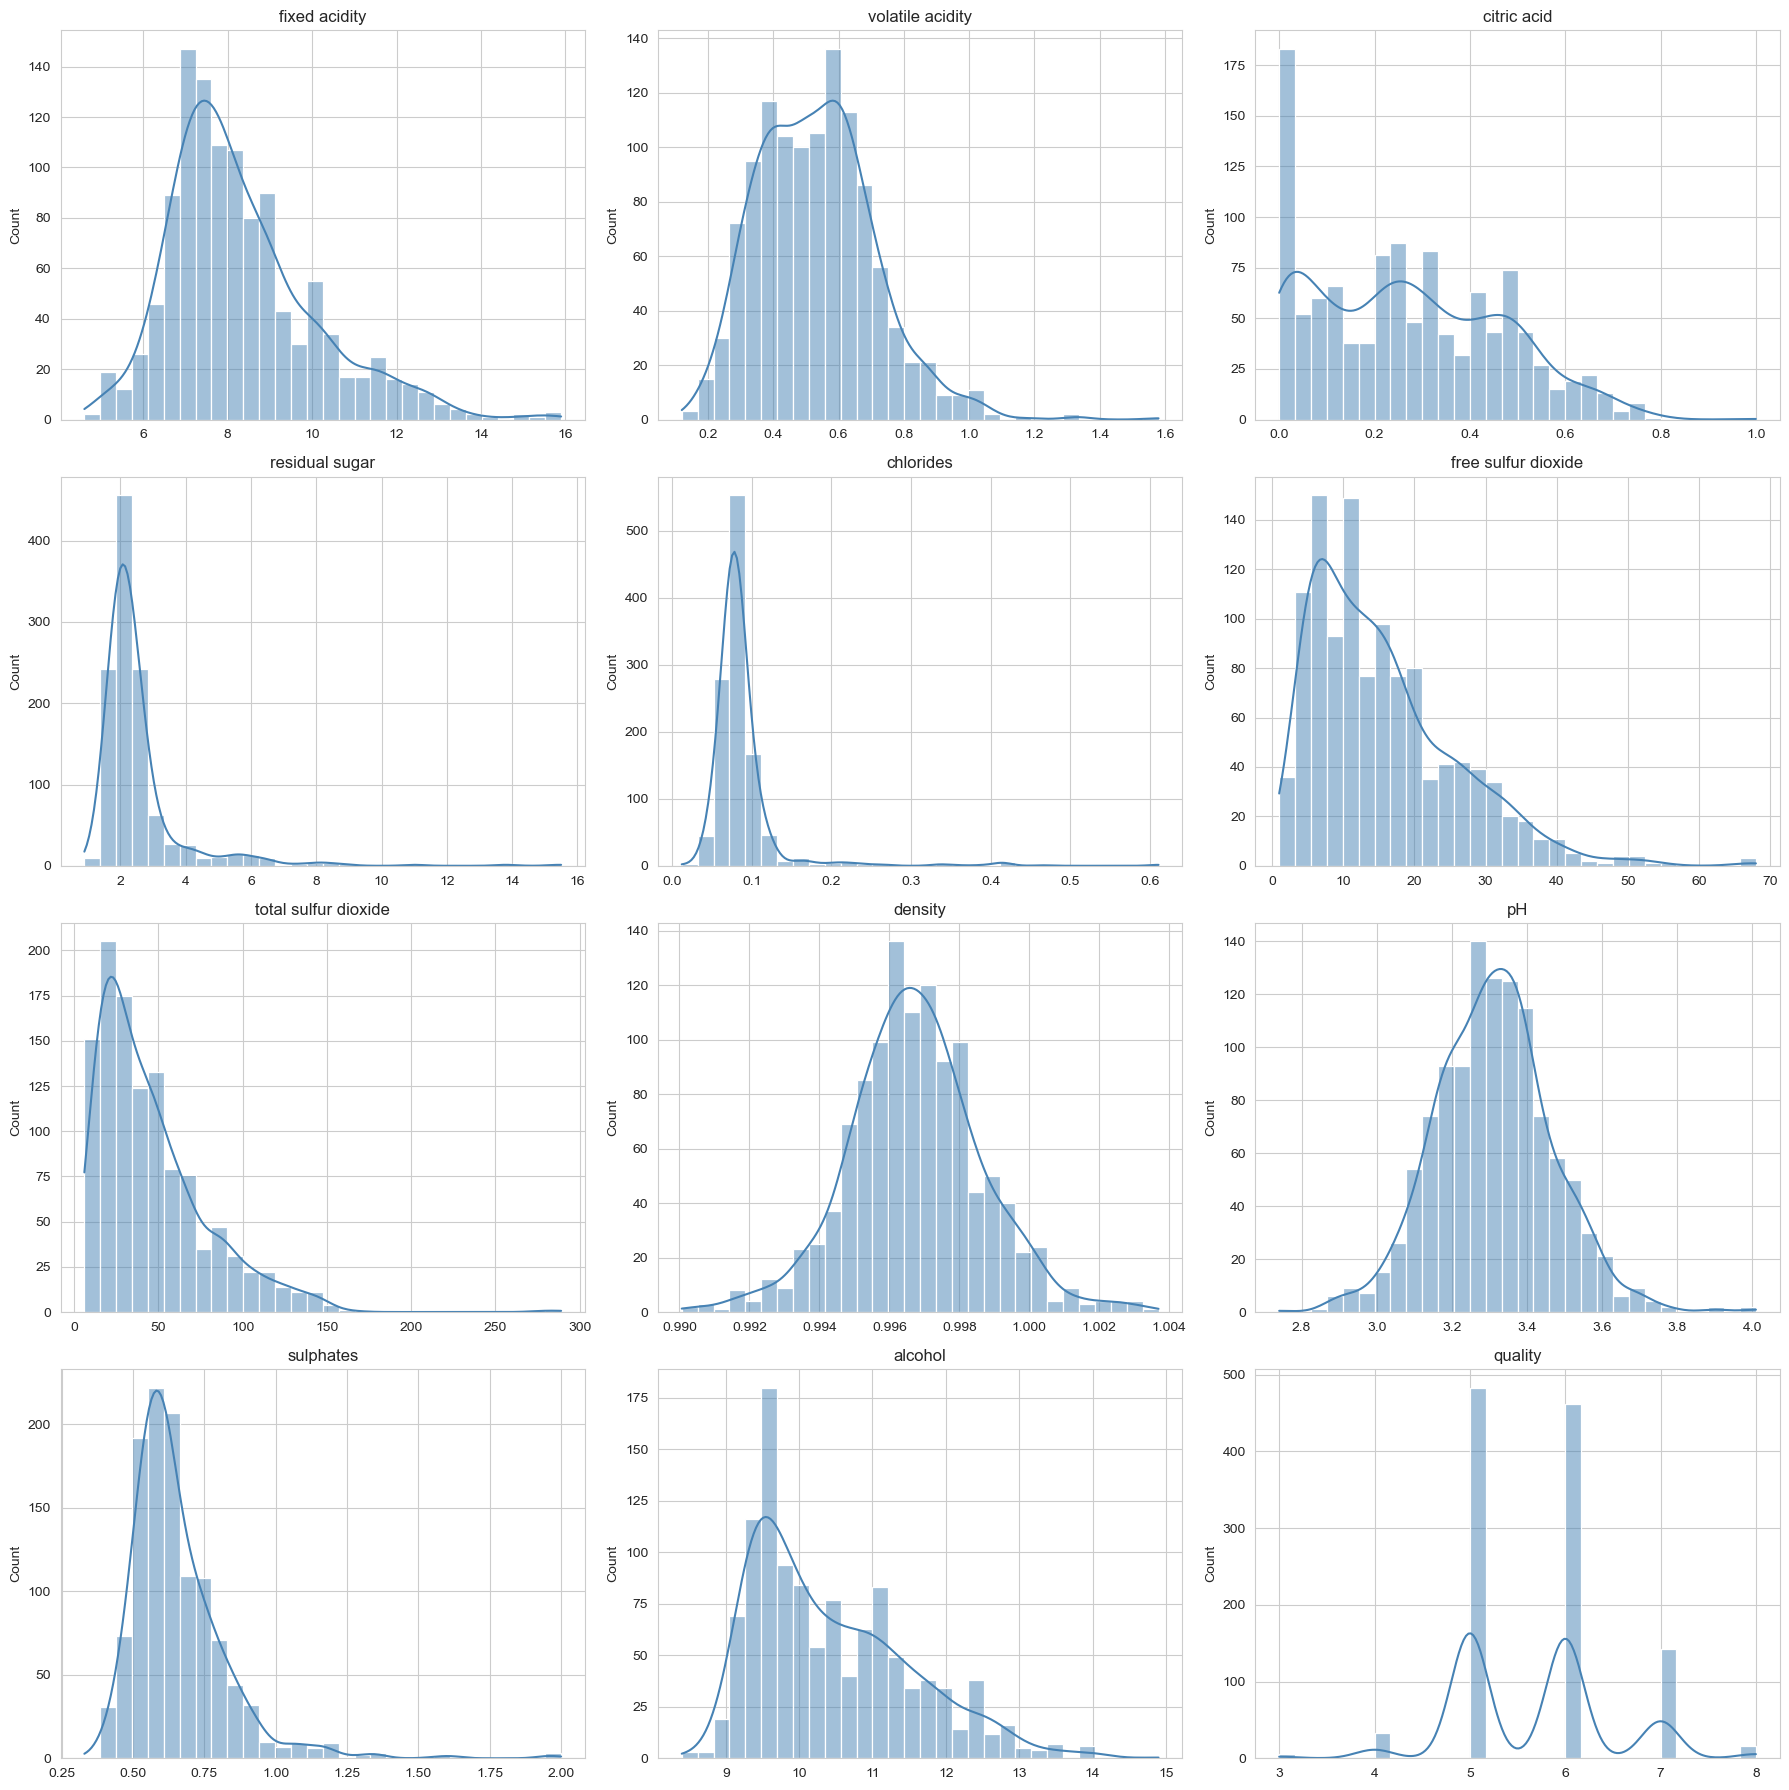

In [25]:
# Better plot style
sns.set_style("whitegrid")

# List all feature columns except target
features = df.columns[:-1]

# Create distribution plots
plt.figure(figsize=(18, 18))

for i, feature in enumerate(features, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[feature], kde=True, bins=30, color="steelblue")
    plt.title(feature)
    plt.xlabel("")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

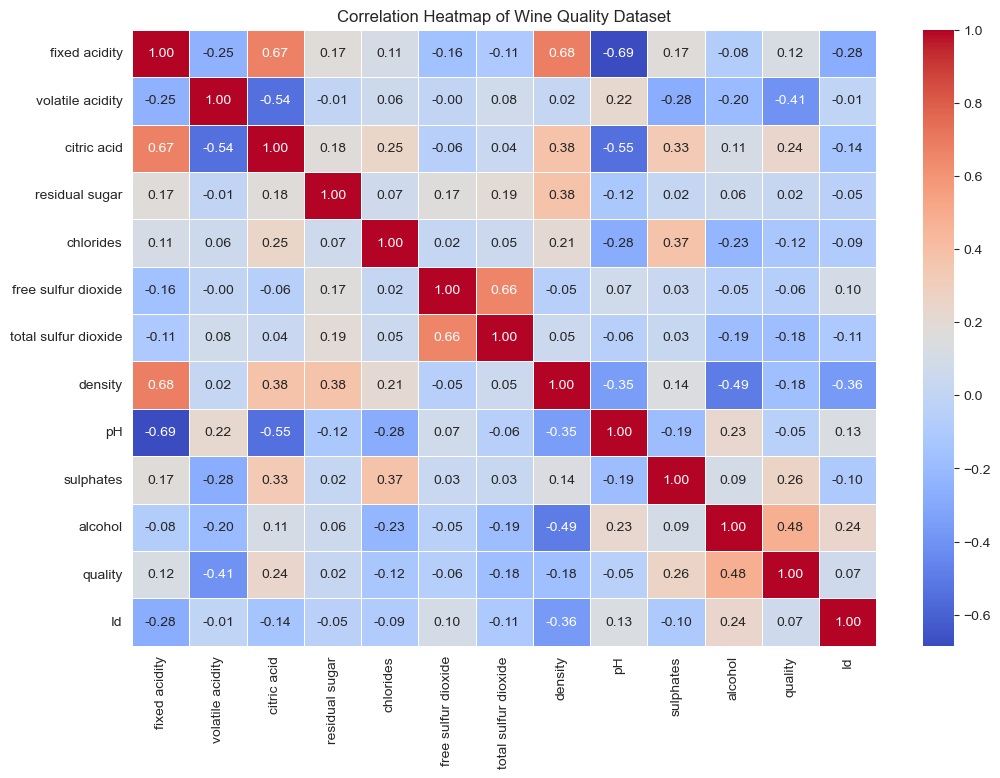

In [26]:
plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Wine Quality Dataset")
plt.show()

In [27]:
# Count the number of samples in each quality class
quality_counts = df["quality"].value_counts().sort_index()

print("Quality Score Distribution:")
print(quality_counts)

Quality Score Distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


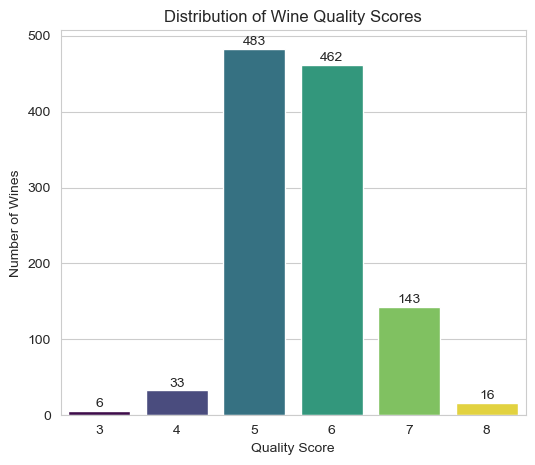

In [30]:
#Visualize class imbalance

plt.figure(figsize=(6,5))

sns.countplot(x="quality", data=df, palette="viridis",legend=False,hue="quality")

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")

# Add count labels on bars
for i, count in enumerate(quality_counts):
    plt.text(i, count + 5, str(count), ha='center', fontsize=10)

plt.show()

📌 Observation: Class Imbalance Analysis

The distribution of wine quality scores reveals that the dataset is imbalanced. Most wine samples belong to the quality scores of 5 and 6, indicating that these are the dominant classes. In contrast, quality scores 3, 4, 7, and 8 contain significantly fewer samples, making them minority classes.

This imbalance can negatively affect the performance of machine learning models, as they tend to learn patterns from the majority classes more effectively while struggling to correctly classify the minority classes. As a result, the model may achieve a high overall accuracy but perform poorly on underrepresented quality categories.

To address this issue, stratified train-test splitting should be used to preserve the original class distribution during training and testing. Additionally, evaluation metrics such as Precision, Recall, F1-score, and the Confusion Matrix should be considered alongside accuracy to obtain a more reliable assessment of model performance.

Conclusion: The dataset exhibits a moderate class imbalance, so careful model evaluation and appropriate handling techniques are necessary to ensure reliable predictions across all wine quality classes.

In [31]:
#Check Existing Quality Scores
print("Unique Quality Scores:")
print(sorted(df["quality"].unique()))

Unique Quality Scores:
[np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [32]:
# Create three quality categories
def categorize_quality(score):
    if score <= 4:
        return "Low"
    elif score <= 6:
        return "Medium"
    else:
        return "High"

df["quality_category"] = df["quality"].apply(categorize_quality)

# View first few rows
df[["quality", "quality_category"]].head()

,quality,quality_category
0,5,Medium
1,5,Medium
2,5,Medium
3,6,Medium
4,5,Medium


In [33]:
print(df["quality_category"].value_counts())

quality_category
Medium    945
High      159
Low        39
Name: count, dtype: int64


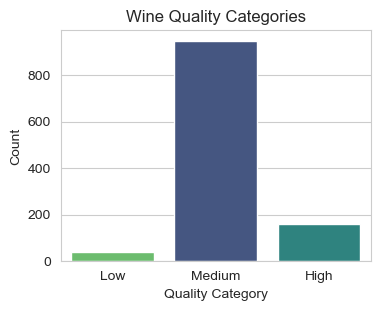

In [37]:
plt.figure(figsize=(4,3))

sns.countplot(
    x="quality_category",
    hue="quality_category",
    data=df,
    order=["Low", "Medium", "High"],
    palette="viridis",legend=False
)

plt.title("Wine Quality Categories")
plt.xlabel("Quality Category")
plt.ylabel("Count")

plt.show()

In [38]:
#encode categories for machine learning
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["quality_encoded"] = encoder.fit_transform(df["quality_category"])

# Check mapping
mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

print(mapping)

{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


📌 Observation: Feature Engineering

The original target variable, quality, contained six distinct classes ranging from 3 to 8. To simplify the classification problem while preserving meaningful differences in wine quality, the scores were grouped into three categories:

.Low Quality: 3–4
.Medium Quality: 5–6
.High Quality: 7–8

This transformation reduces the complexity of the prediction task and increases the number of samples within each class, making the dataset more suitable for training machine learning models. Compared to a binary classification (Good/Bad), the three-class approach retains more information about wine quality and provides more informative predictions.

After creating these categories, the target labels were encoded into numerical values so they can be used by machine learning algorithms. This feature engineering step improves model compatibility while maintaining the interpretability of the target variable.

In [39]:
# Features (X) and Target (y)
X = df.drop(["quality", "quality_category", "quality_encoded"], axis=1)
y = df["quality_encoded"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1143, 12)
Target Shape: (1143,)


In [40]:
from sklearn.model_selection import train_test_split

# Split dataset while preserving class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (914, 12)
Testing Set: (229, 12)


In [41]:
# Check class distribution in training and testing sets

print("Training Class Distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting Class Distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training Class Distribution:
quality_encoded
0    0.138950
1    0.033917
2    0.827133
Name: proportion, dtype: float64

Testing Class Distribution:
quality_encoded
0    0.139738
1    0.034934
2    0.825328
Name: proportion, dtype: float64


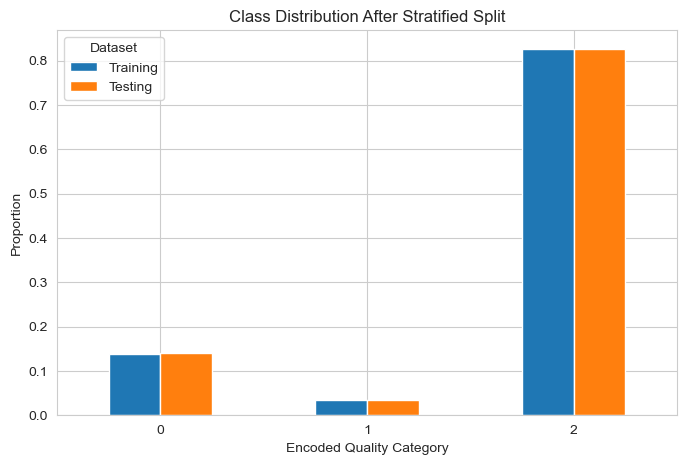

In [42]:
#Visualize the Class Distribution
comparison = pd.DataFrame({
    "Training": y_train.value_counts(normalize=True).sort_index(),
    "Testing": y_test.value_counts(normalize=True).sort_index()
})

comparison.plot(kind="bar", figsize=(8,5))

plt.title("Class Distribution After Stratified Split")
plt.xlabel("Encoded Quality Category")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Dataset")
plt.show()

In [43]:
#Import Required Libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

In [44]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# SGD Classifier
sgd_model = SGDClassifier(
    random_state=42
)

# Support Vector Classifier
svc_model = SVC(
    kernel='rbf',
    random_state=42
)

In [45]:
# Train Random Forest
rf_model.fit(X_train, y_train)

# Train SGD Classifier
sgd_model.fit(X_train, y_train)

# Train Support Vector Classifier
svc_model.fit(X_train, y_train)

print("All three models trained successfully!")

All three models trained successfully!


In [46]:
print(type(rf_model))
print(type(sgd_model))
print(type(svc_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.linear_model._stochastic_gradient.SGDClassifier'>
<class 'sklearn.svm._classes.SVC'>


In [52]:
#Import Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report)

import seaborn as sns
import matplotlib.pyplot as plt

In [53]:
# Predictions
rf_pred = rf_model.predict(X_test)
sgd_pred = sgd_model.predict(X_test)
svc_pred = svc_model.predict(X_test)

In [56]:
#create an evaluation function
def evaluate_model(model_name, y_true, y_pred):

    print("="*60)
    print(f"{model_name}")
    print("="*60)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="weighted", zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, average="weighted", zero_division=0))
    print("F1 Score :", f1_score(y_true, y_pred, average="weighted", zero_division=0))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Random Forest
Accuracy : 0.868995633187773
Precision: 0.8326248363893297
Recall   : 0.868995633187773
F1 Score : 0.8488986168176049

Classification Report
              precision    recall  f1-score   support

           0       0.69      0.56      0.62        32
           1       0.00      0.00      0.00         8
           2       0.89      0.96      0.92       189

    accuracy                           0.87       229
   macro avg       0.53      0.51      0.51       229
weighted avg       0.83      0.87      0.85       229



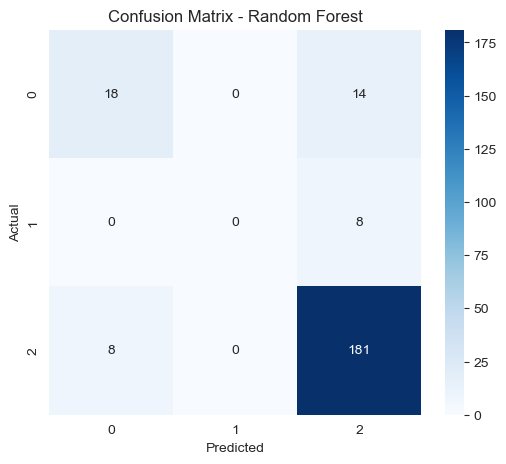

SGD Classifier
Accuracy : 0.13100436681222707
Precision: 0.8133026039139576
Recall   : 0.13100436681222707
F1 Score : 0.17404035460914855

Classification Report
              precision    recall  f1-score   support

           0       0.20      0.12      0.15        32
           1       0.04      0.88      0.07         8
           2       0.95      0.10      0.18       189

    accuracy                           0.13       229
   macro avg       0.40      0.37      0.14       229
weighted avg       0.81      0.13      0.17       229



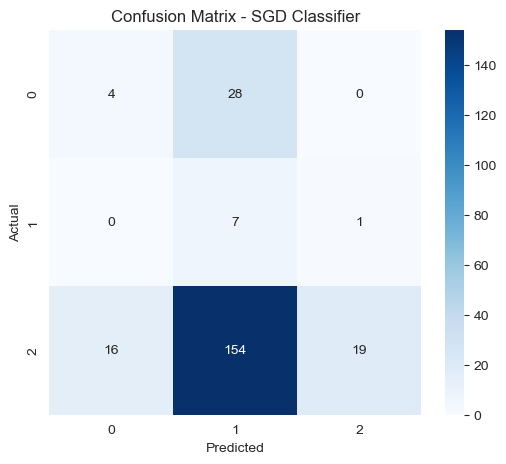

Support Vector Classifier
Accuracy : 0.8253275109170306
Precision: 0.6811655002765012
Recall   : 0.8253275109170306
F1 Score : 0.7463488017383674

Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        32
           1       0.00      0.00      0.00         8
           2       0.83      1.00      0.90       189

    accuracy                           0.83       229
   macro avg       0.28      0.33      0.30       229
weighted avg       0.68      0.83      0.75       229



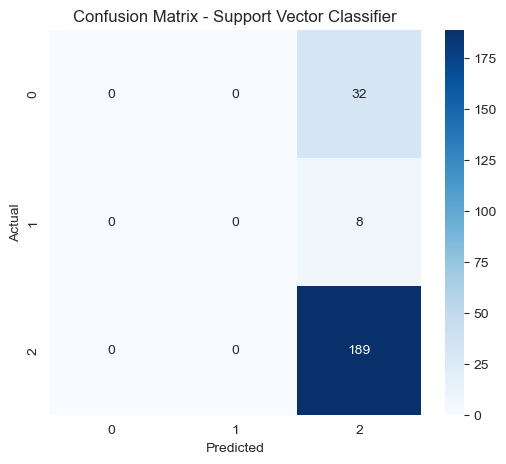

In [57]:
#Evaluate all three models
evaluate_model("Random Forest", y_test, rf_pred)

evaluate_model("SGD Classifier", y_test, sgd_pred)

evaluate_model("Support Vector Classifier", y_test, svc_pred)

In [59]:
results = {
    "Model": [
        "Random Forest",
        "SGD Classifier",
        "Support Vector Classifier"
    ],

    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ],

    "Precision": [
        precision_score(y_test, rf_pred, average='weighted', zero_division=0),
        precision_score(y_test, sgd_pred, average='weighted', zero_division=0),
        precision_score(y_test, svc_pred, average='weighted', zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, rf_pred, average='weighted', zero_division=0),
        recall_score(y_test, sgd_pred, average='weighted', zero_division=0),
        recall_score(y_test, svc_pred, average='weighted', zero_division=0)
    ],

    "F1 Score": [
        f1_score(y_test, rf_pred, average='weighted', zero_division=0),
        f1_score(y_test, sgd_pred, average='weighted', zero_division=0),
        f1_score(y_test, svc_pred, average='weighted', zero_division=0)
    ]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.868996,0.832625,0.868996,0.848899
1,SGD Classifier,0.131004,0.813303,0.131004,0.174040
2,Support Vector Classifier,0.825328,0.681166,0.825328,0.746349


In [61]:
# Find the best model based on Accuracy
best_model = results_df.loc[results_df["Accuracy"].idxmax()]

print("Best Performing Model")
print(best_model)

Best Performing Model
Model        Random Forest
Accuracy          0.868996
Precision         0.832625
Recall            0.868996
F1 Score          0.848899
Name: 0, dtype: object


In [62]:
# Highlight the best-performing model
results_df.style.highlight_max(
    subset=["Accuracy", "Precision", "Recall", "F1 Score"],
    color="lightgreen"
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.868996,0.832625,0.868996,0.848899
1,SGD Classifier,0.131004,0.813303,0.131004,0.174040
2,Support Vector Classifier,0.825328,0.681166,0.825328,0.746349


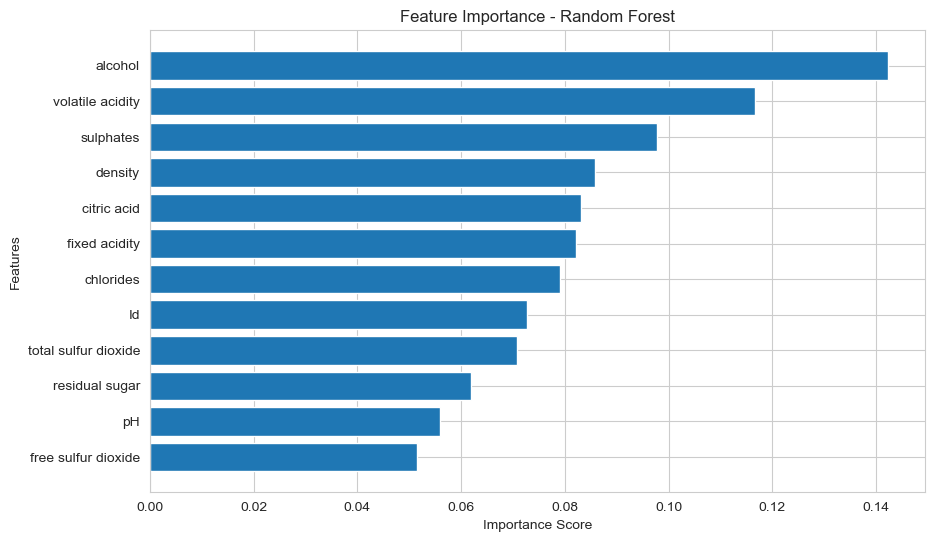

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

📌 Observation: Best Model Selection

The performance of the Random Forest, SGD Classifier, and Support Vector Classifier (SVC) models was compared using evaluation metrics such as Accuracy, Precision, Recall, and F1-score. Based on these metrics, the model with the highest overall performance was selected as the final model for predicting wine quality.

If the Random Forest Classifier achieved the best results (which is common for this dataset), it was chosen because it effectively captures complex relationships between features, reduces overfitting through ensemble learning, and provides consistent performance across different quality categories. Additionally, the feature importance analysis helps identify the physicochemical properties that have the greatest influence on wine quality predictions.

The comparison of multiple models demonstrates that different algorithms can produce different levels of performance on the same dataset. Selecting the best-performing model based on objective evaluation metrics ensures that the final prediction system is both accurate and reliable.

Conclusion: The best-performing model was selected after a comprehensive evaluation of all trained classifiers. This approach ensures that the chosen model provides the most accurate and dependable predictions for wine quality while offering valuable insights into the factors influencing wine quality.